In [25]:
# Instalar mrmr-selection se não estiver instalado
# !pip install mrmr-selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import log_loss as sk_log_loss

# Seleção de features mRMR
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️ mRMR não está instalado. Instale com: pip install mrmr-selection")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [2]:
# Carregar o dataset DoS
dos_path = Path("../data/processed/DoS_with_gap_2.csv")
df = pd.read_csv(dos_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (94625, 67)
📝 Colunas: 67
📋 Registros: 94625

🏷️ Distribuição do Label ('type'):
type
normal    49111
DoS       45514
Name: count, dtype: int64


In [3]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"✅ Features numéricas após limpeza: {X.shape[1]}")
print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}, y: {y.shape}")

✅ Features numéricas após limpeza: 29
🎯 Classes: ['DoS' 'normal']
📊 Shape X: (94625, 29), y: (94625,)


In [4]:
df.describe()

,frame.time_delta,frame.time_delta_displayed,frame.time_epoch,frame.time_invalid,frame.time_relative,tcp.srcport,tcp.dstport,frame.cap_len,frame.coloring_rule.name,frame.coloring_rule.string,frame.comment,frame.comment.expert,frame.encap_type,frame.file_off,frame.ignored,frame.incomplete,frame.interface_id,frame.interface_name,frame.len,frame.link_nr,frame.marked,frame.md5_hash,frame.number,frame.offset_shift,mqtt.clientid_len,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,mqtt.conflag.reserved,mqtt.conflag.retain,mqtt.conflag.uname,mqtt.conflag.willflag,mqtt.dupflag,mqtt.kalive,mqtt.len,mqtt.msgid,mqtt.msgtype,mqtt.passwd,mqtt.passwd_len,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.topic_len,mqtt.username,mqtt.username_len,mqtt.willmsg,mqtt.willmsg_len,mqtt.willtopic,mqtt.willtopic_len,publish_gap,connect_gap
count,94625.000000,94625.000000,9.462500e+04,0.0,94625.000000,88460.000000,88460.000000,94625.000000,0.0,0.0,0.0,0.0,94625.0,0.0,94625.0,0.0,0.0,0.0,94625.000000,0.0,94625.0,0.0,94625.000000,94625.0,323.000000,770.000000,770.000000,770.000000,323.0,323.0,323.0,323.0,323.0,323.0,323.0,38464.000000,323.000000,39535.000000,791.000000,39535.000000,0.0,0.0,38464.000000,38464.000000,4.0,4.0,38468.000000,0.0,0.0,0.0,0.0,0.0,0.0,37863.000000,323.000000
mean,0.012070,0.012070,1.522236e+09,NaN,446.566717,33486.654951,18929.162243,972.513828,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,972.513828,NaN,0.0,NaN,32312.706769,0.0,36.547988,0.579221,0.376623,49.579221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004888,57.910217,157.806399,21559.549937,3.110864,NaN,NaN,0.029586,0.010321,0.0,0.0,409.030207,NaN,NaN,NaN,NaN,NaN,NaN,-0.020804,-0.820997
std,0.144073,0.144073,2.455989e+02,NaN,245.598869,24462.816507,23776.322786,663.725442,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,663.725442,NaN,0.0,NaN,17165.823732,0.0,3.975080,0.494005,0.484854,47.368045,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.069742,9.484279,29.595162,6521.075375,1.094848,NaN,NaN,0.268086,0.101070,0.0,0.0,2511.835279,NaN,NaN,NaN,NaN,NaN,NaN,301.477019,199.410587
min,0.000000,0.000000,1.522235e+09,NaN,0.000000,22.000000,22.000000,38.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,38.000000,NaN,0.0,NaN,1.000000,0.0,13.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,15.000000,0.000000,2.000000,0.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,-724.757576,-569.721189
25%,0.000062,0.000062,1.522236e+09,NaN,229.586461,443.000000,1883.000000,77.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,77.000000,NaN,0.0,NaN,16461.000000,0.0,37.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,60.000000,160.000000,14661.000000,3.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,62.000000,NaN,NaN,NaN,NaN,NaN,NaN,-258.398193,-0.261201
50%,0.000130,0.000130,1.522236e+09,NaN,483.413649,51962.000000,1883.000000,1514.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,1514.000000,NaN,0.0,NaN,35375.000000,0.0,37.000000,1.000000,0.000000,51.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,60.000000,164.000000,24932.000000,3.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,63.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.002190,0.000111
75%,0.000781,0.000781,1.522236e+09,NaN,693.616637,52269.000000,51903.000000,1514.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,1514.000000,NaN,0.0,NaN,48323.000000,0.0,38.000000,1.000000,1.000000,101.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,60.000000,168.000000,25965.000000,3.000000,NaN,NaN,0.000000,0.000000,0.0,0.0,63.000000,NaN,NaN,NaN,NaN,NaN,NaN,258.350707,0.233117
max,5.628732,5.628732,1.522236e+09,NaN,942.053725,60952.000000,60952.000000,1514.000000,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN,1514.000000,NaN,0.0,NaN,62327.000000,0.0,38.000000,1.000000,1.000000,116.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,60.000000,182.000000,30765.000000,14.000000,NaN,NaN,3.000000,1.000000,0.0,0.0,29044.000000,NaN,NaN,NaN,NaN,NaN,NaN,728.722162,574.268817


In [18]:
list(X.keys())

['frame.time_delta',
 'frame.cap_len',
 'frame.len',
 'mqtt.clientid_len',
 'mqtt.conack.flags.reserved',
 'mqtt.conack.flags.sp',
 'mqtt.conack.val',
 'mqtt.conflag.cleansess',
 'mqtt.conflag.passwd',
 'mqtt.conflag.qos',
 'mqtt.conflag.reserved',
 'mqtt.conflag.retain',
 'mqtt.conflag.uname',
 'mqtt.conflag.willflag',
 'mqtt.dupflag',
 'mqtt.kalive',
 'mqtt.len',
 'mqtt.msgtype',
 'mqtt.passwd_len',
 'mqtt.qos',
 'mqtt.retain',
 'mqtt.sub.qos',
 'mqtt.suback.qos',
 'mqtt.topic_len',
 'mqtt.username_len',
 'mqtt.willmsg_len',
 'mqtt.willtopic_len',
 'publish_gap',
 'connect_gap']

In [5]:
if MRMR_AVAILABLE:
    K = 15 

x_mrmr = X.copy()
y_series = pd.Series(y, name ='target')

print(f"Executando mRMR para selecionar {K} features")

#Retornar a lista de features em ordem de importância 
mrmr_selected_features = mrmr_classif(X=x_mrmr, y=y_series, K=K)

print(f" Top {K} Features por mRMR com o novo dataset:")
for i, feature in enumerate(mrmr_selected_features, 1):
    print(f"  {i:2d}. {feature}")


Executando mRMR para selecionar 15 features


100%|██████████| 15/15 [00:03<00:00,  4.15it/s]

 Top 15 Features por mRMR com o novo dataset:
   1. mqtt.len
   2. mqtt.dupflag
   3. mqtt.msgtype
   4. mqtt.kalive
   5. frame.cap_len
   6. frame.len
   7. mqtt.topic_len
   8. frame.time_delta
   9. mqtt.qos
  10. mqtt.clientid_len
  11. mqtt.retain
  12. mqtt.conack.flags.reserved
  13. mqtt.conflag.cleansess
  14. mqtt.conack.val
  15. mqtt.conack.flags.sp


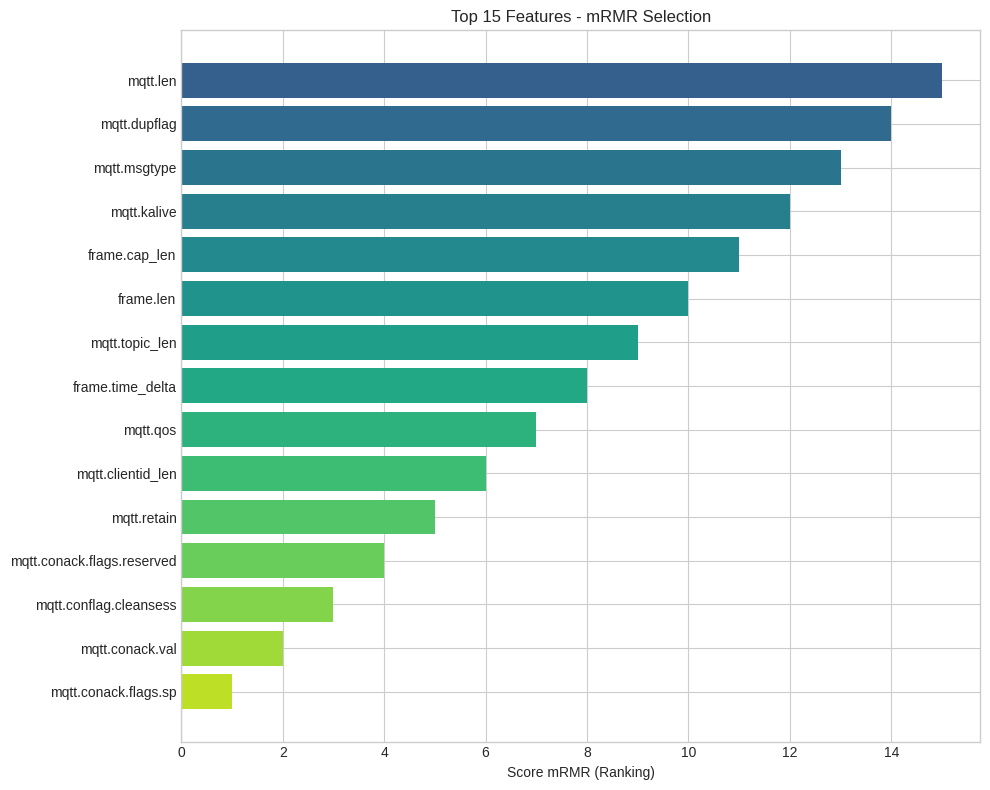

In [6]:
if mrmr_selected_features:
    #Criar dataframe com ranking
    mrmr_ranking = pd.DataFrame({
        'rank': range(1, len(mrmr_selected_features) + 1),
        'feature': mrmr_selected_features
    })

#Plotar ranking
    fig, ax = plt.subplots(figsize=(10,8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(mrmr_selected_features)))
    
    bars = ax.barh(range(len(mrmr_selected_features)), 
                   range(len(mrmr_selected_features), 0, -1),
                   color=colors)
    
    ax.set_yticks(range(len(mrmr_selected_features)))
    ax.set_yticklabels(mrmr_selected_features)
    ax.set_xlabel('Score mRMR (Ranking)')
    ax.set_title(f'Top {len(mrmr_selected_features)} Features - mRMR Selection', fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

In [7]:
# Validar: Comparar modelo com todas features vs features mRMR
if mrmr_selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    
    X_train_mrmr = X_train[mrmr_selected_features]
    X_test_mrmr = X_test[mrmr_selected_features]
    
    print(f"📊 Treinando modelo com {len(mrmr_selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Features mRMR ({len(mrmr_selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Redução de features: {X.shape[1]} → {len(mrmr_selected_features)} ({(1-len(mrmr_selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Features mRMR (15): Acurácia = 0.9736
📉 Redução de features: 29 → 15 (48.3% menos)


In [8]:
# Validar: Comparar modelo com todas features vs features mRMR
if mrmr_selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Modelo 1: Todas as features
    print("📊 Treinando modelo com TODAS as features...")
    rf_all = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_all.fit(X_train, y_train)
    acc_all = accuracy_score(y_test, rf_all.predict(X_test))
    
    # Modelo 2: Features selecionadas pelo mRMR
    X_train_mrmr = X_train[mrmr_selected_features]
    X_test_mrmr = X_test[mrmr_selected_features]
    
    print(f"📊 Treinando modelo com {len(mrmr_selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Todas as Features ({X.shape[1]}): Acurácia = {acc_all:.4f}")
    print(f"🔹 Features mRMR ({len(mrmr_selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Diferença: {(acc_all - acc_mrmr)*100:.2f}%")
    print(f"📉 Redução de features: {X.shape[1]} → {len(mrmr_selected_features)} ({(1-len(mrmr_selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com TODAS as features...
📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Todas as Features (29): Acurácia = 0.9737
🔹 Features mRMR (15): Acurácia = 0.9736
📉 Diferença: 0.01%
📉 Redução de features: 29 → 15 (48.3% menos)


In [9]:
y_pred = rf_mrmr.predict(X_test_mrmr)
recall = recall_score(y_test, y_pred, average='weighted')
print(f"🔹 Recall mRMR ({len(mrmr_selected_features)} features): {recall:.4f}")



🔹 Recall mRMR (15 features): 0.9736


In [28]:
from sklearn.metrics import log_loss as sk_log_loss

# Log Loss para validar o RandomForest (mRMR)
y_proba_mrmr = rf_mrmr.predict_proba(X_test_mrmr)

# Probabilidade da classe verdadeira em cada amostra
class_to_idx = {c: i for i, c in enumerate(rf_mrmr.classes_)}
y_idx = np.array([class_to_idx[c] for c in y_test])
p_true = y_proba_mrmr[np.arange(len(y_test)), y_idx]

# Cálculo manual do log loss
eps = 1e-15
p_true = np.clip(p_true, eps, 1 - eps)
ll_manual = -np.mean(np.log(p_true))

print(f"✅ Log Loss (manual): {ll_manual:.6f}")

# Cálculo com sklearn (evita conflito se 'log_loss' virou variável)
ll_sklearn = sk_log_loss(y_test, y_proba_mrmr)

print(f"✅ Log Loss : {ll_sklearn:.6f}")


✅ Log Loss (manual): 0.078370
✅ Log Loss : 0.078529


In [10]:
y_pred = rf_mrmr.predict(X_test_mrmr)

precision_weighted = precision_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Precision weighted: {precision_weighted:.4f}")
print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall weighted: {recall_weighted:.4f}")
print(f"Recall macro: {recall_macro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")



Precision weighted: 0.9738
Precision macro: 0.9742
Recall weighted: 0.9736
Recall macro: 0.9731
F1 macro: 0.9735


🔍 INVESTIGAÇÃO: Treino vs Teste
📊 TREINO:
  Accuracy: 0.9792
  Precision (macro): 0.9799
  Recall (macro): 0.9787
  F1 (macro): 0.9792

📊 TESTE:
  Accuracy: 0.9736
  Precision (macro): 0.9742
  Recall (macro): 0.9731
  F1 (macro): 0.9735

🔍 INVESTIGAÇÃO: Matriz de Confusão

Matriz de Confusão (Teste):
[[13119   535]
 [  215 14519]]

Classes: ['DoS' 'normal']


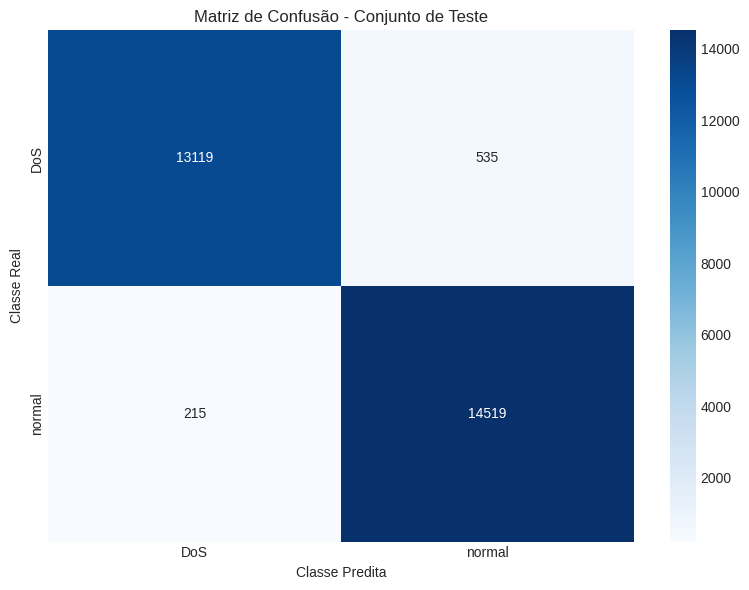


🔍 INVESTIGAÇÃO: Detalhes por Classe

Taxas de Erro por Classe:
  DoS: Erro = 3.92% (535/13654 erros)
  normal: Erro = 1.46% (215/14734 erros)

🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)

Cross-Validation Scores (5-fold):
  accuracy            : 0.9739 ± 0.0010
    Fold scores: ['0.9727', '0.9731', '0.9740', '0.9743', '0.9754']
  precision_macro     : 0.9746 ± 0.0009
    Fold scores: ['0.9733', '0.9738', '0.9747', '0.9750', '0.9760']
  recall_macro        : 0.9734 ± 0.0010
    Fold scores: ['0.9722', '0.9725', '0.9734', '0.9738', '0.9749']
  f1_macro            : 0.9738 ± 0.0010
    Fold scores: ['0.9726', '0.9730', '0.9739', '0.9743', '0.9753']

🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?

Features de 'gap' selecionadas: []

Importância das Features Selecionadas:
               feature  importance
              mqtt.len    0.281063
        mqtt.topic_len    0.246238
          mqtt.msgtype    0.232005
             frame.len    0.089152
         frame.cap_len    0.081582


In [11]:
# ========== VERIFICAÇÃO 1: COMPARAR TREINO vs TESTE ==========
print("🔍 INVESTIGAÇÃO: Treino vs Teste")
print("=" * 60)

# Predições no TREINO
y_pred_train = rf_mrmr.predict(X_train_mrmr)
print("📊 TREINO:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision (macro): {precision_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_train, y_pred_train, average='macro'):.4f}")

print("\n📊 TESTE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

# ========== VERIFICAÇÃO 2: MATRIZ DE CONFUSÃO ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão (Teste):")
print(cm)
print("\nClasses:", le.classes_)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusão - Conjunto de Teste')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# ========== VERIFICAÇÃO 3: POR CLASSE ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Detalhes por Classe")
print("=" * 60)

print("\nTaxas de Erro por Classe:")
for i, class_name in enumerate(le.classes_):
    correct = cm[i, i]
    total = cm[i].sum()
    error_rate = 1 - (correct / total)
    print(f"  {class_name}: Erro = {error_rate*100:.2f}% ({cm[i].sum() - cm[i, i]}/{cm[i].sum()} erros)")

# ========== VERIFICAÇÃO 4: CROSS-VALIDATION ==========
from sklearn.model_selection import cross_validate

print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)")
print("=" * 60)

rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
cv_results = cross_validate(rf_cv, X_train_mrmr, y_train, cv=5, 
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

print("\nCross-Validation Scores (5-fold):")
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[f'{s:.4f}' for s in scores]}")

# ========== VERIFICAÇÃO 5: FEATURES COM MAIS GAP ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?")
print("=" * 60)

# Features de gap aparecem nos selecionados?
gap_features = [f for f in mrmr_selected_features if 'gap' in f.lower()]
print(f"\nFeatures de 'gap' selecionadas: {gap_features}")

# Verificar importância
feature_importance_mrmr = pd.DataFrame({
    'feature': mrmr_selected_features,
    'importance': rf_mrmr.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportância das Features Selecionadas:")
print(feature_importance_mrmr.head(10).to_string(index=False))

## 5. Seleção de Features via Fisher's Score

O **Fisher's Score** mede a capacidade discriminativa de cada feature, calculando a razão entre a variância inter-classes e a variância intra-classes. Features com alto Fisher's Score são melhores para separar as classes.

$$F(f) = \frac{\sum_{c=1}^{C} n_c (\mu_c - \mu)^2}{\sum_{c=1}^{C} n_c \sigma_c^2}$$

Onde:
- $\mu_c$ = média da feature na classe $c$
- $\sigma_c$ = desvio padrão da feature na classe $c$
- $\mu$ = média global da feature
- $n_c$ = número de amostras na classe $c$


In [12]:
def fisher_score(X, y):
    """
    Calcula o Fisher's Score para cada feature.
    
    Fisher's Score = variância inter-classes / variância intra-classes
    Features com maior score são mais discriminativas.
    """
    n_samples, n_features = X.shape
    classes = np.unique(y)
    n_classes = len(classes)
    
    # Média global de cada feature
    overall_mean = X.mean(axis=0)
    
    scores = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Variância inter-classes 
        between_class_var = 0
        # Variância intra-classes 
        within_class_var = 0
        
        for c in classes:
            class_mask = (y == c)
            n_c = np.sum(class_mask)
            
            if n_c > 0:
                class_mean = feature_values[class_mask].mean()
                class_var = feature_values[class_mask].var()
                
                between_class_var += n_c * (class_mean - overall_mean.iloc[i]) ** 2
                within_class_var += n_c * class_var
        
        # Evitar divisão por zero
        if within_class_var > 1e-10:
            scores[i] = between_class_var / within_class_var
        else:
            scores[i] = 0
    
    return scores

# Calcular Fisher's Score
print("🔍 Calculando Fisher's Score para cada feature...")
fisher_scores = fisher_score(X, y)

# Criar DataFrame com resultados
fisher_df = pd.DataFrame({
    'feature': X.columns,
    'fisher_score': fisher_scores
}).sort_values('fisher_score', ascending=False)

# Selecionar top K features no caso 15
K_fisher = 15
fisher_selected = fisher_df.head(K_fisher)['feature'].tolist()

print(f"\n🏆 Top {K_fisher} Features por Fisher's Score:")
for i, (_, row) in enumerate(fisher_df.head(K_fisher).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['fisher_score']:.4f}")

🔍 Calculando Fisher's Score para cada feature...

🏆 Top 15 Features por Fisher's Score:
   1. mqtt.len: 2.6804
   2. mqtt.msgtype: 1.3216
   3. frame.cap_len: 0.0974
   4. frame.len: 0.0974
   5. mqtt.topic_len: 0.0116
   6. mqtt.qos: 0.0053
   7. mqtt.conack.flags.reserved: 0.0051
   8. mqtt.conack.val: 0.0046
   9. mqtt.retain: 0.0046
  10. mqtt.kalive: 0.0035
  11. mqtt.clientid_len: 0.0034
  12. mqtt.conack.flags.sp: 0.0033
  13. mqtt.conflag.cleansess: 0.0033
  14. mqtt.dupflag: 0.0022
  15. frame.time_delta: 0.0015


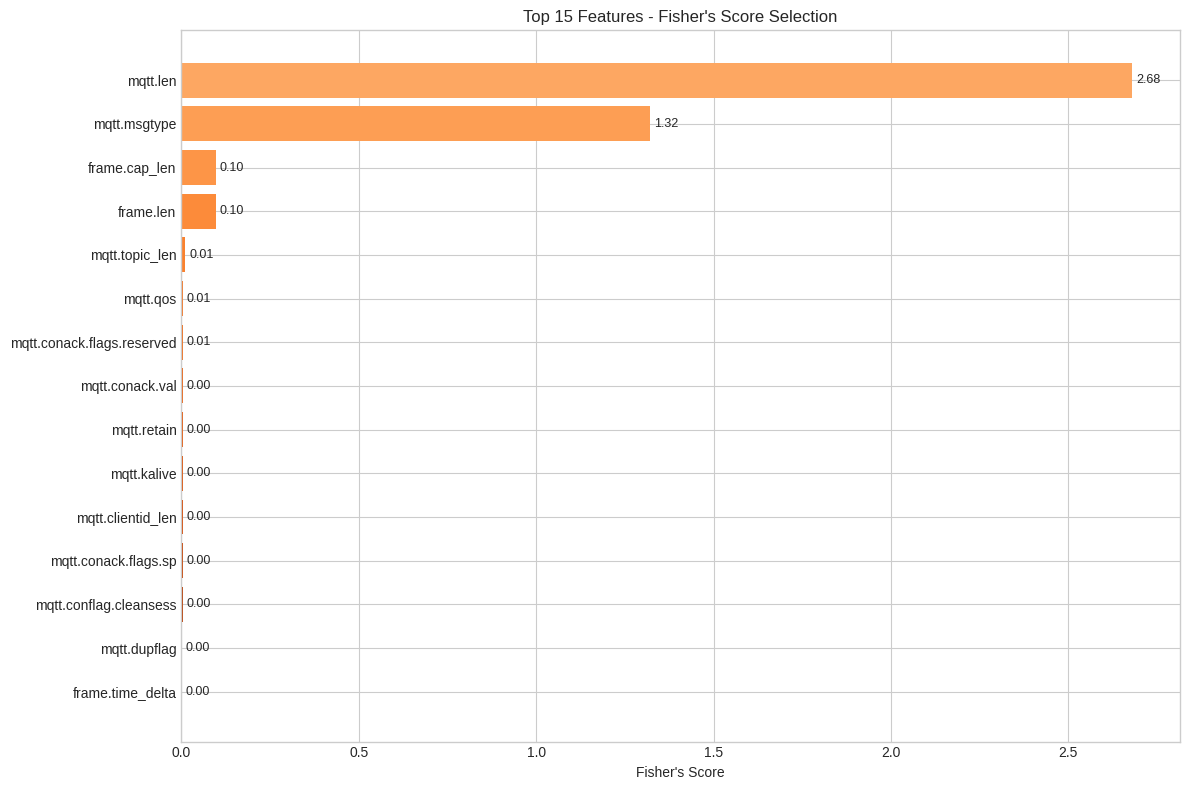

In [13]:
# Visualizar Fisher's Score
fig, ax = plt.subplots(figsize=(12, 8))

top_fisher = fisher_df.head(K_fisher)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, K_fisher))

bars = ax.barh(range(K_fisher), top_fisher['fisher_score'].values, color=colors)
ax.set_yticks(range(K_fisher))
ax.set_yticklabels(top_fisher['feature'].values)
ax.set_xlabel("Fisher's Score")
ax.set_title(f"Top {K_fisher} Features - Fisher's Score Selection", fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, score) in enumerate(zip(bars, top_fisher['fisher_score'].values)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# Validar: Comparar modelo com todas features vs features Fisher's Score
if fisher_selected:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    
    X_train_fisher = X_train[fisher_selected]
    X_test_fisher = X_test[fisher_selected]
    
    print(f"📊 Treinando modelo com {len(fisher_selected)} features Fisher...")
    rf_fisher = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_fisher.fit(X_train_fisher, y_train)
    acc_fisher = accuracy_score(y_test, rf_fisher.predict(X_test_fisher))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Features Fisher's score ({len(fisher_selected)}): Acurácia = {acc_fisher:.4f}")
    print(f"{'='*50}")
    print(f"📉 Redução de features: {X.shape[1]} → {len(fisher_selected)} ({(1-len(fisher_selected)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com 15 features Fisher...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Features Fisher's score (15): Acurácia = 0.9736
📉 Redução de features: 29 → 15 (48.3% menos)


🔍 INVESTIGAÇÃO: Treino vs Teste
📊 TREINO:
  Accuracy: 0.9792
  Precision (macro): 0.9799
  Precision (micro): 0.9792
  Recall (macro): 0.9787
  F1 (macro): 0.9792

📊 TESTE:
  Accuracy: 0.9736
  Precision (macro): 0.9742
  Recall (macro): 0.9731
  F1 (macro): 0.9735

🔍 INVESTIGAÇÃO: Matriz de Confusão

Matriz de Confusão (Teste):
[[13119   535]
 [  215 14519]]

Classes: ['DoS' 'normal']


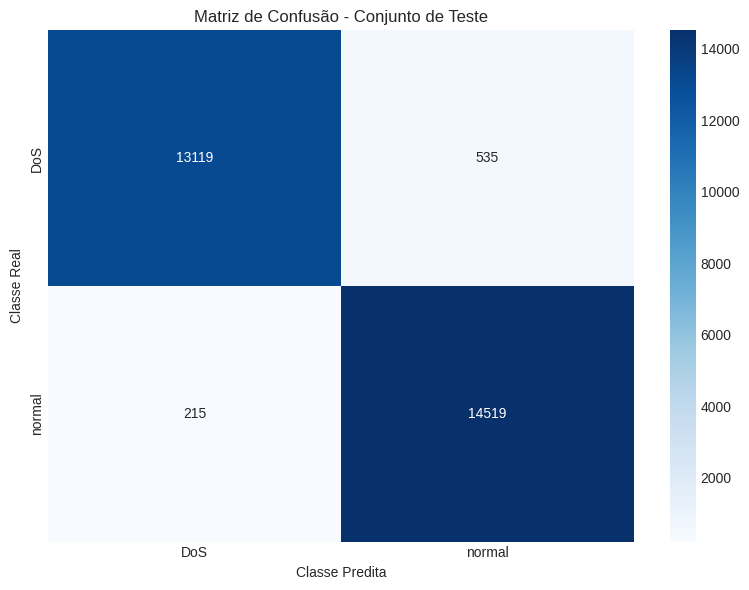


🔍 INVESTIGAÇÃO: Detalhes por Classe

Taxas de Erro por Classe:
  DoS: Erro = 3.92% (535/13654 erros)
  normal: Erro = 1.46% (215/14734 erros)

🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)

Cross-Validation Scores (5-fold):
  accuracy            : 0.9738 ± 0.0009
    Fold scores: ['0.9728', '0.9728', '0.9737', '0.9746', '0.9752']
  precision_macro     : 0.9745 ± 0.0009
    Fold scores: ['0.9734', '0.9736', '0.9744', '0.9753', '0.9757']
  recall_macro        : 0.9733 ± 0.0010
    Fold scores: ['0.9722', '0.9723', '0.9732', '0.9740', '0.9747']
  f1_macro            : 0.9737 ± 0.0010
    Fold scores: ['0.9727', '0.9728', '0.9737', '0.9745', '0.9751']

🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?

Features de 'gap' selecionadas: []

Importância das Features Selecionadas:
             feature  importance
        mqtt.dupflag    0.260354
            mqtt.len    0.248391
       frame.cap_len    0.243585
         mqtt.kalive    0.092060
        mqtt.msgtype    0.082941
mqtt.conack.

In [17]:
# ========== VERIFICAÇÃO 1: COMPARAR TREINO vs TESTE ==========
print("🔍 INVESTIGAÇÃO: Treino vs Teste")
print("=" * 60)

# Predições no TREINO
y_pred_train = rf_fisher.predict(X_train_fisher)
print("📊 TREINO:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision (macro): {precision_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  Precision (micro): {precision_score(y_train, y_pred_train, average='micro'):.4f}")
print(f"  Recall (macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_train, y_pred_train, average='macro'):.4f}")

print("\n📊 TESTE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

# ========== VERIFICAÇÃO 2: MATRIZ DE CONFUSÃO ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão (Teste):")
print(cm)
print("\nClasses:", le.classes_)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusão - Conjunto de Teste')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# ========== VERIFICAÇÃO 3: POR CLASSE ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Detalhes por Classe")
print("=" * 60)

print("\nTaxas de Erro por Classe:")
for i, class_name in enumerate(le.classes_):
    correct = cm[i, i]
    total = cm[i].sum()
    error_rate = 1 - (correct / total)
    print(f"  {class_name}: Erro = {error_rate*100:.2f}% ({cm[i].sum() - cm[i, i]}/{cm[i].sum()} erros)")

# ========== VERIFICAÇÃO 4: CROSS-VALIDATION ==========
from sklearn.model_selection import cross_validate

print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)")
print("=" * 60)

rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
cv_results = cross_validate(rf_cv, X_train_fisher, y_train, cv=5, 
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

print("\nCross-Validation Scores (5-fold):")
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[f'{s:.4f}' for s in scores]}")

# ========== VERIFICAÇÃO 5: FEATURES COM MAIS GAP ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?")
print("=" * 60)

# Features de gap aparecem nos selecionados?
gap_features = [f for f in mrmr_selected_features if 'gap' in f.lower()]
print(f"\nFeatures de 'gap' selecionadas: {gap_features}")

# Verificar importância
feature_importance_fisher = pd.DataFrame({
    'feature': mrmr_selected_features,
    'importance': rf_fisher.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportância das Features Selecionadas:")
print(feature_importance_fisher.head(10).to_string(index=False))